In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


STEP 1: Importing Libraries & Setting Seed

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 500

STEP 2: Creating Synthetic Dataset

In [3]:
data = pd.DataFrame({
    "income": np.random.randint(20000, 150000, n),
    "loan_amount": np.random.randint(5000, 50000, n),
    "credit_score": np.random.randint(300, 850, n),
    "employment_type": np.random.choice(["Salaried", "Self-Employed", "Unemployed"], n),
    "years_experience": np.random.randint(0, 20, n)
})

STEP 3: Creating Target Variable

In [4]:
data["loan_status"] = (
    (data["income"] > 50000) &
    (data["credit_score"] > 600) &
    (data["employment_type"] != "Unemployed")
).astype(int)

TEP 4: Introducing Missing Values

In [5]:
for col in ["income", "credit_score"]:
    data.loc[np.random.choice(data.index, 20), col] = np.nan

STEP 5: Adding Outliers

In [6]:
data.loc[np.random.choice(data.index, 5), "income"] = 300000

STEP 6: Saving Dataset

STEP 7: Basic Data Understanding

In [9]:
data.info()
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   income            482 non-null    float64
 1   loan_amount       500 non-null    int64  
 2   credit_score      481 non-null    float64
 3   employment_type   500 non-null    object 
 4   years_experience  500 non-null    int64  
 5   loan_status       500 non-null    int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 23.6+ KB


,income,loan_amount,credit_score,years_experience,loan_status
count,482.000000,500.000000,481.000000,500.000000,500.000000
mean,89508.778008,27753.876000,563.802495,9.218000,0.210000
std,44219.586034,12822.299454,163.535663,5.813611,0.407716
min,20206.000000,5009.000000,300.000000,0.000000,0.000000
25%,56206.250000,16300.750000,420.000000,4.000000,0.000000
50%,87217.500000,28161.000000,563.000000,9.000000,0.000000
75%,124003.000000,39593.000000,701.000000,14.000000,0.000000
max,300000.000000,49912.000000,849.000000,19.000000,1.000000


In [26]:
data.isnull().sum()

,0
income,0
loan_amount,0
credit_score,0
years_experience,0
loan_status,0
employment_type_Self-Employed,0
employment_type_Unemployed,0


STEP 8: Visualization (EDA)

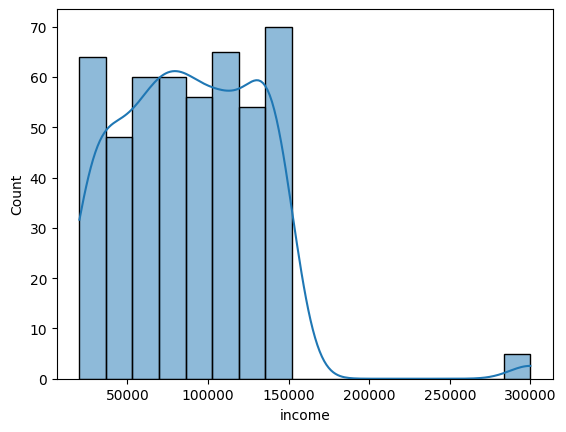

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data["income"], kde=True)
plt.show()



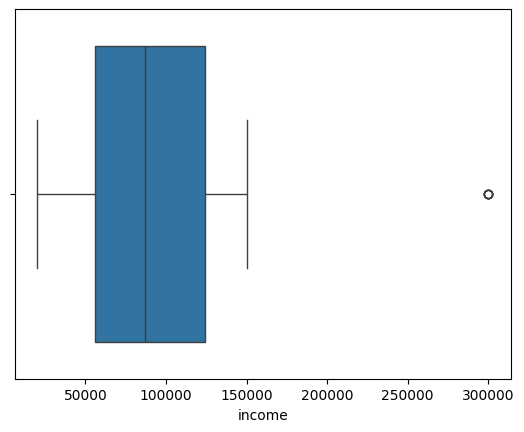

In [11]:
#outliers
sns.boxplot(x=data["income"])
plt.show()


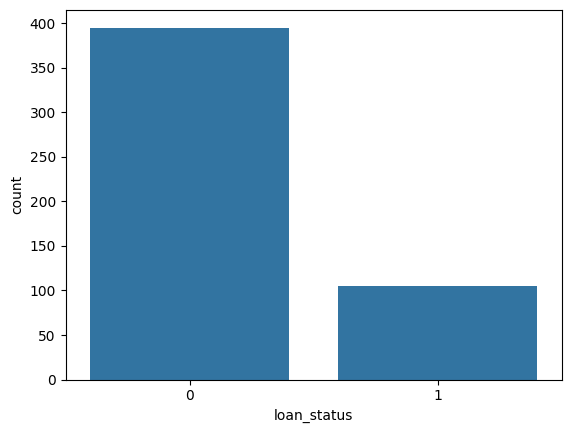

In [12]:
#class balance
sns.countplot(x=data["loan_status"])
plt.show()

STEP 9: Correlation

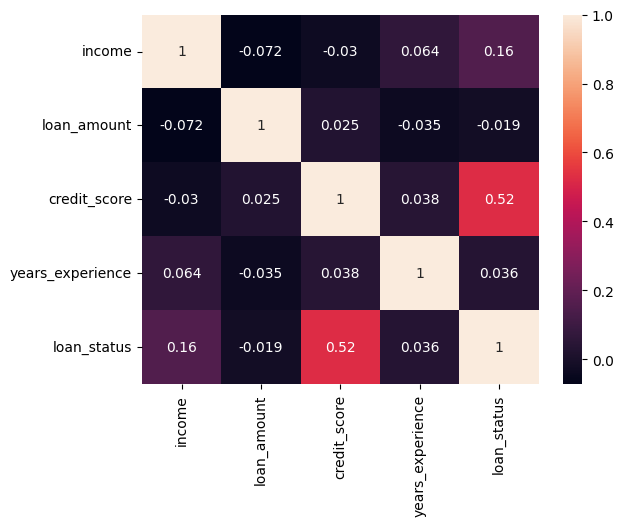

In [13]:
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

STEP 10: Handling Missing Values

In [14]:
data["income"].fillna(data["income"].median(), inplace=True)
data["credit_score"].fillna(data["credit_score"].mean(), inplace=True)

/tmp/ipykernel_7731/1724341357.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["income"].fillna(data["income"].median(), inplace=True)
/tmp/ipykernel_7731/1724341357.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

### Skewness Analysis (Before IQR Capping)

Skewness of numerical columns before IQR capping:
income: -0.07
loan_amount: -0.05
credit_score: 0.08
years_experience: 0.05


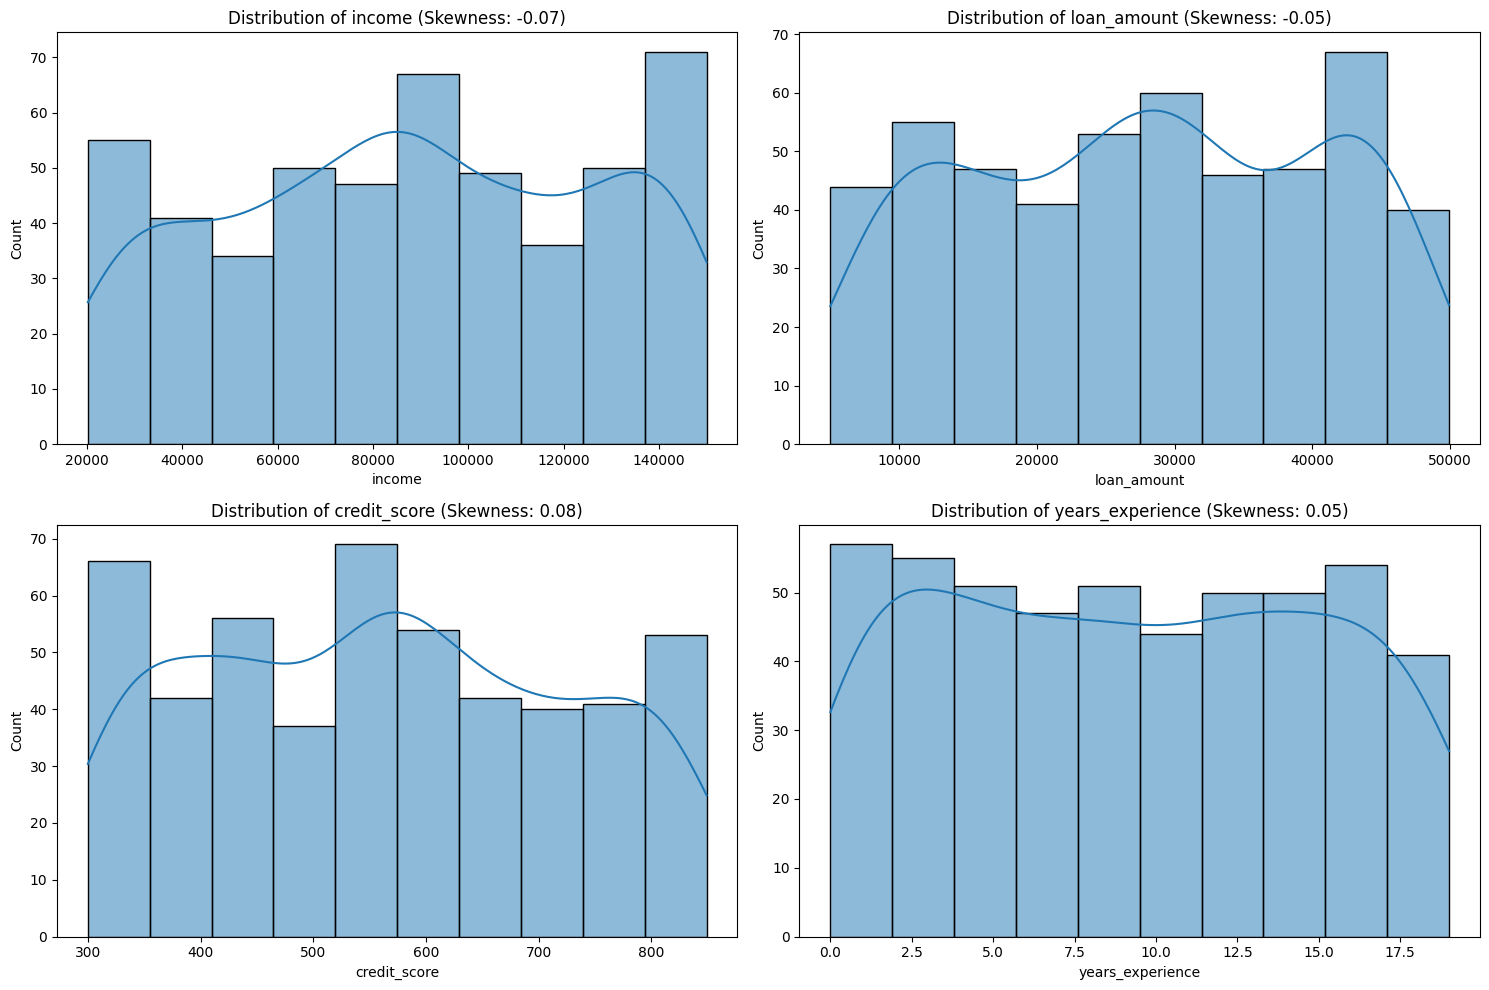

In [39]:
print("Skewness of numerical columns before IQR capping:")
for col in ['income', 'loan_amount', 'credit_score', 'years_experience']:
    print(f"{col}: {data[col].skew():.2f}")

# Visualize distributions to observe skewness
plt.figure(figsize=(15, 10))
for i, col in enumerate(['income', 'loan_amount', 'credit_score', 'years_experience']):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col} (Skewness: {data[col].skew():.2f})')
plt.tight_layout()
plt.show()

### Demonstrating Skewness with Synthetic Data

Skewness of Right Skewed Data: 1.45
Skewness of Left Skewed Data: -1.72


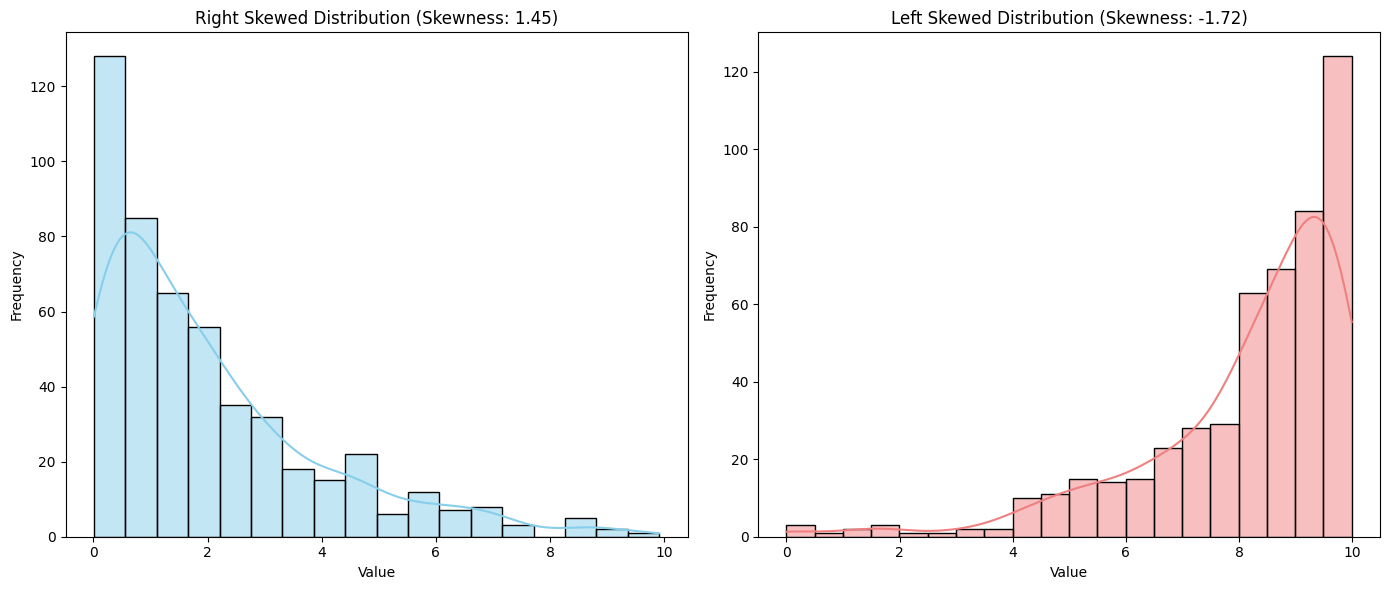

In [40]:
# Generate Right Skewed Data (e.g., exponential distribution)
np.random.seed(42) # for reproducibility
right_skewed_data = pd.Series(np.random.exponential(scale=2, size=500))

# Generate Left Skewed Data (e.g., negative exponential or beta distribution)
# A common way to create left-skewed data is to subtract a right-skewed distribution from a constant
left_skewed_data = pd.Series(10 - np.random.exponential(scale=2, size=500))

# Ensure no negative values for left_skewed if it's meant to be non-negative
left_skewed_data = left_skewed_data.clip(lower=0)

print(f"Skewness of Right Skewed Data: {right_skewed_data.skew():.2f}")
print(f"Skewness of Left Skewed Data: {left_skewed_data.skew():.2f}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(right_skewed_data, kde=True, color='skyblue')
plt.title(f'Right Skewed Distribution (Skewness: {right_skewed_data.skew():.2f})')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(left_skewed_data, kde=True, color='lightcoral')
plt.title(f'Left Skewed Distribution (Skewness: {left_skewed_data.skew():.2f})')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Box Plots for Skewed Data

Box plots can also visually indicate skewness:
- For right-skewed data, the right whisker is typically longer, and the median is closer to the left side of the box.
- For left-skewed data, the left whisker is typically longer, and the median is closer to the right side of the box.

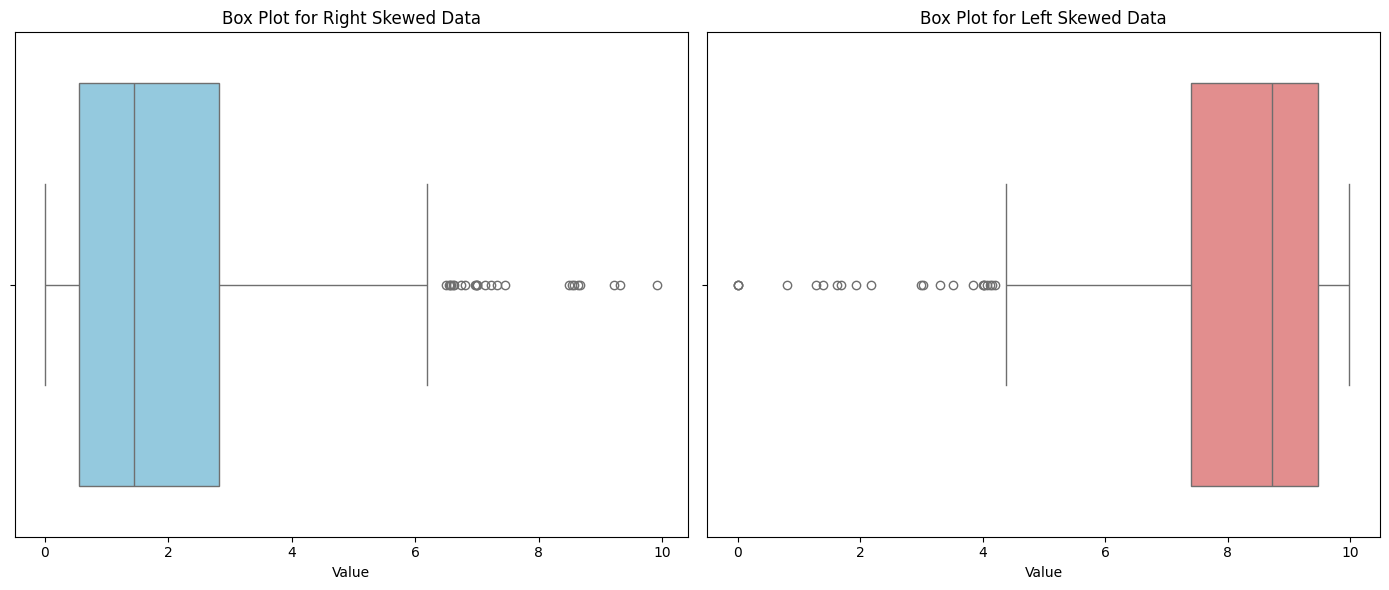

In [41]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=right_skewed_data, color='skyblue')
plt.title('Box Plot for Right Skewed Data')
plt.xlabel('Value')

plt.subplot(1, 2, 2)
sns.boxplot(x=left_skewed_data, color='lightcoral')
plt.title('Box Plot for Left Skewed Data')
plt.xlabel('Value')

plt.tight_layout()
plt.show()

STEP 11: Handling Outliers

### What is IQR (Interquartile Range)?

The Interquartile Range (IQR) is a measure of statistical dispersion, or the spread of the middle 50% of the data. It is the range between the first quartile (Q1, 25th percentile) and the third quartile (Q3, 75th percentile) of a dataset.

Mathematically, IQR = Q3 - Q1.

#### How it's used for Outlier Detection:

Outliers are often defined as data points that fall below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`. This method provides a data-driven way to identify values that are significantly different from the rest of the dataset.

#### Handling Outliers with IQR (Winsorization/Capping):

Instead of removing outliers, which can lead to loss of valuable data, a common approach is winsorization or capping. This involves replacing the outlier values with the nearest non-outlier value (i.e., `Q1 - 1.5 * IQR` for lower outliers and `Q3 + 1.5 * IQR` for upper outliers).

This method is generally preferred over simple hard-coding limits (like `np.clip` with fixed values) because it adapts to the actual distribution of your data.

In [27]:
# Function to cap outliers using IQR
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.clip(lower=lower_bound, upper=upper_bound)

# Apply IQR-based capping to 'income' and 'credit_score'
data["income"] = cap_outliers_iqr(data["income"])
data["credit_score"] = cap_outliers_iqr(data["credit_score"])

print("Outliers in 'income' and 'credit_score' handled using IQR capping.")

# Verify by checking descriptive statistics again (optional)
display(data[['income', 'credit_score']].describe())

Outliers in 'income' and 'credit_score' handled using IQR capping.


,income,credit_score
count,500.000000,500.000000
mean,87926.292000,563.802495
std,38408.712421,160.392044
min,20206.000000,300.000000
25%,57909.000000,429.000000
50%,87217.500000,563.802495
75%,122969.750000,695.250000
max,150000.000000,849.000000


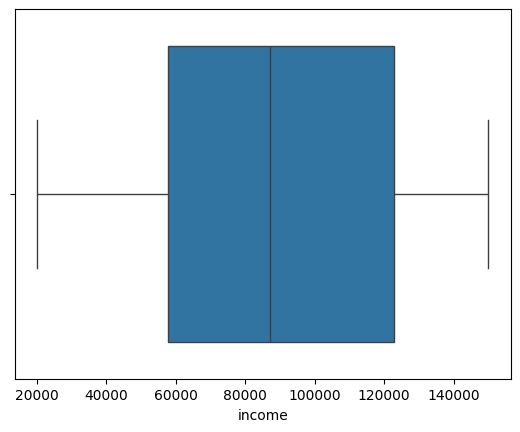

In [28]:
#outliers
sns.boxplot(x=data["income"])
plt.show()


In [29]:
# Verify by checking descriptive statistics again
display(data[['income', 'credit_score']].describe())

,income,credit_score
count,500.000000,500.000000
mean,87926.292000,563.802495
std,38408.712421,160.392044
min,20206.000000,300.000000
25%,57909.000000,429.000000
50%,87217.500000,563.802495
75%,122969.750000,695.250000
max,150000.000000,849.000000


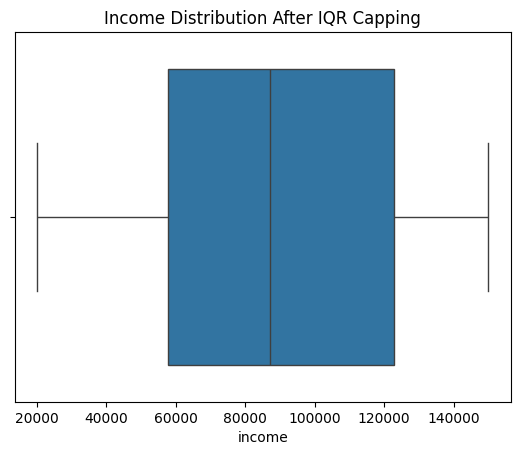

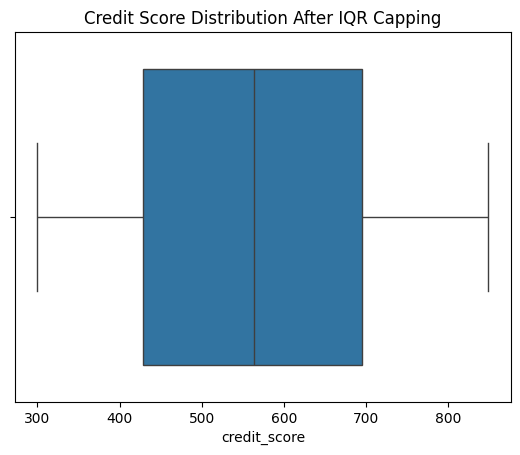

In [30]:
# Visualize the distribution of 'income' after capping
sns.boxplot(x=data["income"])
plt.title("Income Distribution After IQR Capping")
plt.show()

# Visualize the distribution of 'credit_score' after capping
sns.boxplot(x=data["credit_score"])
plt.title("Credit Score Distribution After IQR Capping")
plt.show()

STEP 12: Encoding Categorical Variable

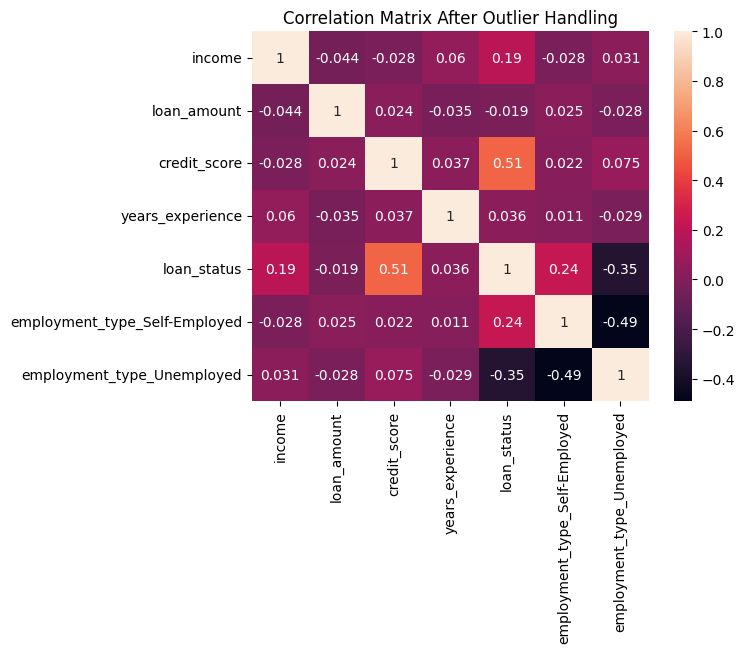

In [36]:
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix After Outlier Handling")
plt.show()

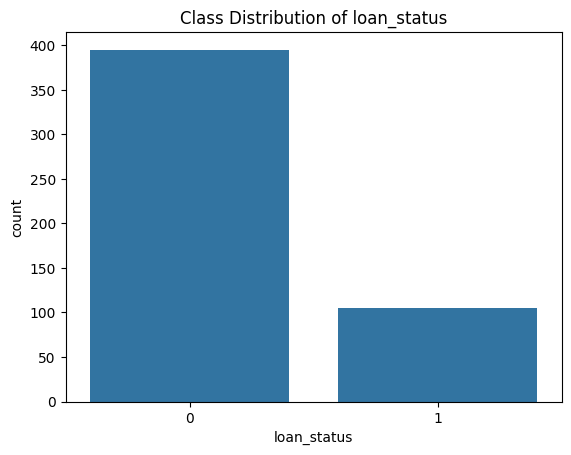

In [37]:
sns.countplot(x=data["loan_status"])
plt.title("Class Distribution of loan_status")
plt.show()

In [16]:
data = pd.get_dummies(data, columns=["employment_type"], drop_first=True)

STEP 13: Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split

X = data.drop("loan_status", axis=1)
y = data["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

STEP 14 : Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["income", "loan_amount", "credit_score", "years_experience"]

# Fit ONLY on training data
scaler.fit(X_train[num_cols])

# Transform both
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [19]:
from sklearn.model_selection import train_test_split

X = data.drop("loan_status", axis=1)
y = data["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.86
Precision: 0.6666666666666666
Recall: 0.6
F1 Score: 0.631578947368421


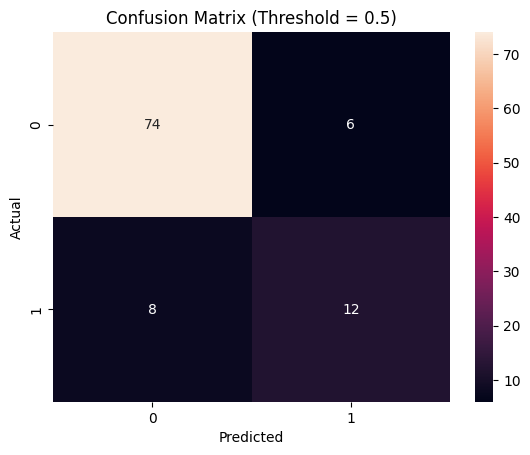

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Apply threshold = 0.5
y_pred_05 = (y_prob >= 0.5).astype(int)

# Compute confusion matrix
cm_05 = confusion_matrix(y_test, y_pred_05)

# Plot
plt.figure()
sns.heatmap(cm_05, annot=True, fmt='d')
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
from sklearn.metrics import roc_auc_score
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.879375


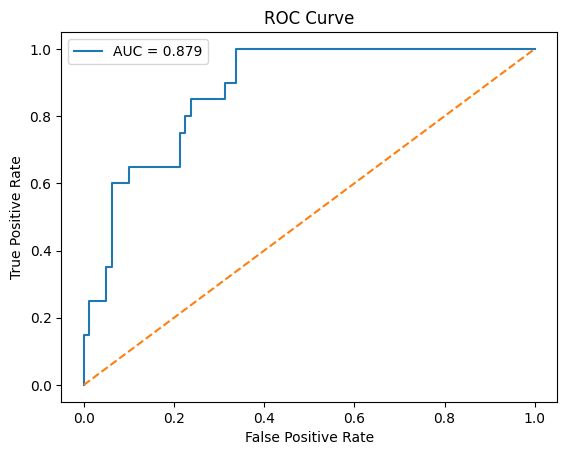

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

# Random model reference line
plt.plot([0, 1], [0, 1], linestyle='--')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()